In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("DailyDelhiClimateTrain.csv")

In [31]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   str    
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.2 KB


In [33]:
df.columns

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='str')

In [34]:
df.shape

(1462, 5)

In [35]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [36]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df.head()


,date,meantemp,humidity,wind_speed,meanpressure,year,month
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1


In [37]:
    df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
year            0
month           0
dtype: int64

In [38]:
temp_array = np.array(df['meantemp'])

print("Mean Temp:", np.mean(temp_array))
print("Max Temp:", np.max(temp_array))
print("Min Temp:", np.min(temp_array))

Mean Temp: 25.495520655761762
Max Temp: 38.71428571428572
Min Temp: 6.0


In [39]:
yearly_temp = df.groupby('year')['meantemp'].mean()
yearly_humidity = df.groupby('year')['humidity'].mean()

print(yearly_temp)
print(yearly_humidity)

year
2013    24.791494
2014    25.010673
2015    25.114591
2016    27.103373
2017    10.000000
Name: meantemp, dtype: float64
year
2013     63.046292
2014     59.767942
2015     61.430490
2016     58.740174
2017    100.000000
Name: humidity, dtype: float64


In [40]:
monthly_temp = df.groupby('month')['meantemp'].mean()
monthly_temp


month
1     13.311914
2     17.620422
3     22.914103
4     29.376614
5     33.315889
6     33.734011
7     30.995782
8     30.601777
9     30.433216
10    27.113154
11    20.656855
12    15.666317
Name: meantemp, dtype: float64

In [41]:
corr = df[['meantemp','humidity','wind_speed','meanpressure']].corr()
corr


,meantemp,humidity,wind_speed,meanpressure
meantemp,1.000000,-0.571951,0.306468,-0.038818
humidity,-0.571951,1.000000,-0.373972,0.001734
wind_speed,0.306468,-0.373972,1.000000,-0.020670
meanpressure,-0.038818,0.001734,-0.020670,1.000000


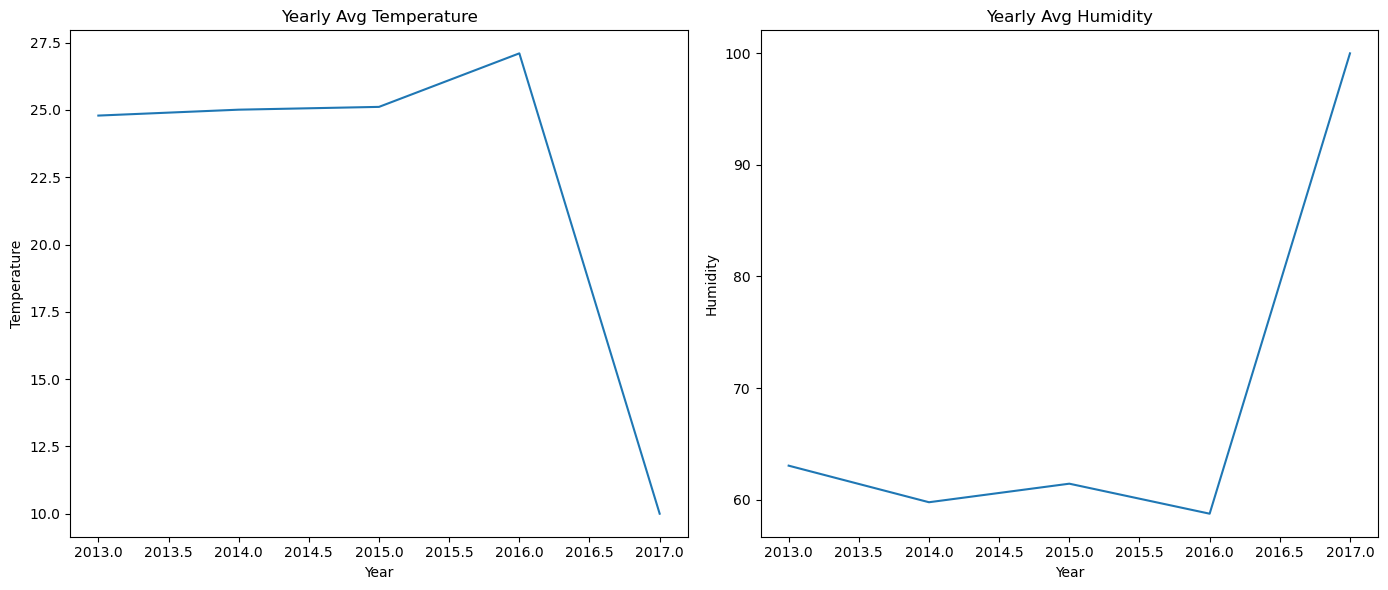

In [42]:
plt.figure(figsize=(14,6))

# Temperature
plt.subplot(1,2,1)
plt.plot(yearly_temp.index, yearly_temp.values)
plt.title("Yearly Avg Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature")

# Humidity
plt.subplot(1,2,2)
plt.plot(yearly_humidity.index, yearly_humidity.values)
plt.title("Yearly Avg Humidity")
plt.xlabel("Year")
plt.ylabel("Humidity")

plt.tight_layout()
plt.show()

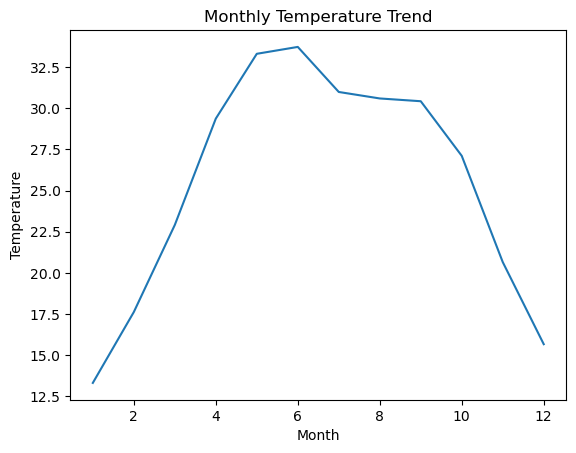

In [43]:
plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()


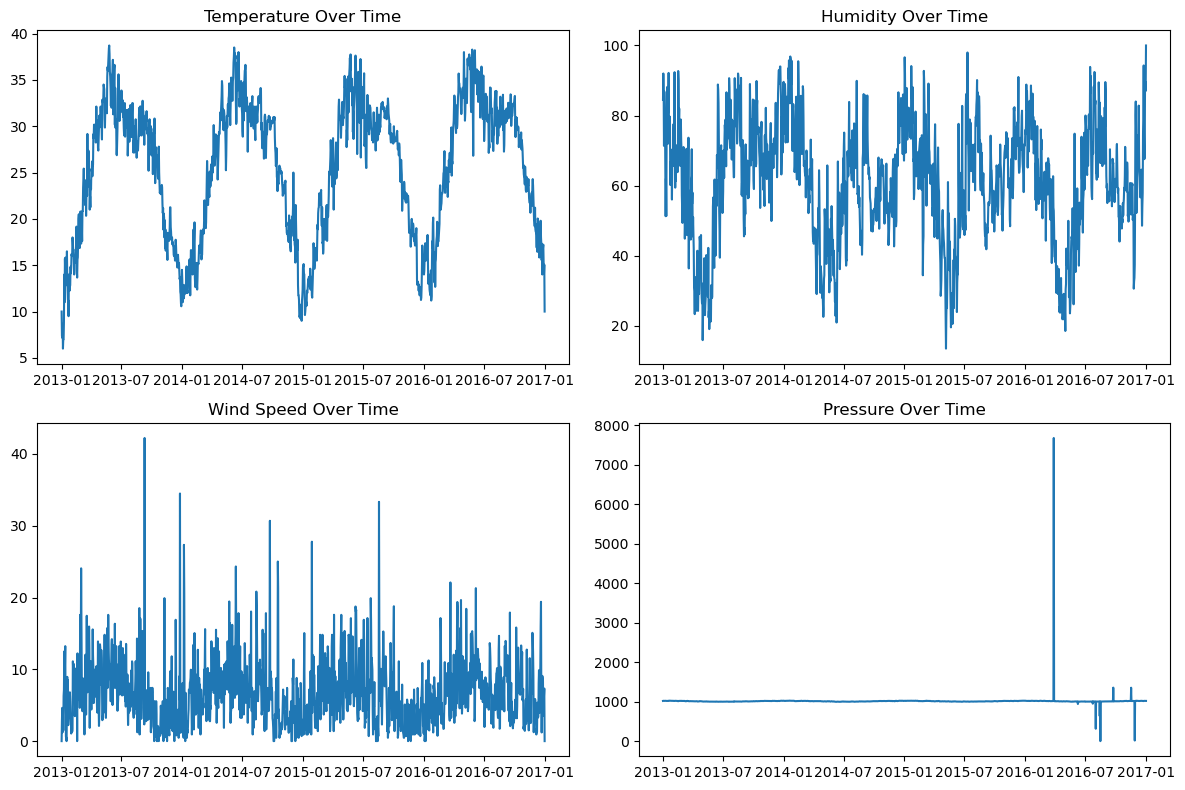

In [44]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(df['date'], df['meantemp'])
plt.title("Temperature Over Time")

plt.subplot(2,2,2)
plt.plot(df['date'], df['humidity'])
plt.title("Humidity Over Time")

plt.subplot(2,2,3)
plt.plot(df['date'], df['wind_speed'])
plt.title("Wind Speed Over Time")

plt.subplot(2,2,4)
plt.plot(df['date'], df['meanpressure'])
plt.title("Pressure Over Time")

plt.tight_layout()
plt.show()


In [46]:
df.groupby('month')['temperature'].mean()

KeyError: 'Column not found: temperature'

In [47]:
df[['temperature','rainfall']].corr()

KeyError: "None of [Index(['temperature', 'rainfall'], dtype='str')] are in the [columns]"